In [1]:
import scanpy as sc
import pandas as pd

# Load QC-processed datasets
adata1 = sc.read_h5ad("GSE114725_qc.h5ad")
adata2 = sc.read_h5ad("GSE176078_qc.h5ad")

print(adata1)
print(adata2)

AnnData object with n_obs × n_vars = 33342 × 14875
    obs: 'patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
AnnData object with n_obs × n_vars = 82954 × 29733
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'


In [2]:
# Use only highly variable genes for dimensionality reduction
adata1_hvg = adata1[:, adata1.var["highly_variable"]].copy()
adata2_hvg = adata2[:, adata2.var["highly_variable"]].copy()

print(adata1_hvg)
print(adata2_hvg)

AnnData object with n_obs × n_vars = 33342 × 2000
    obs: 'patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
AnnData object with n_obs × n_vars = 82954 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'


C:\Users\annam\anaconda3\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\annam\anaconda3\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


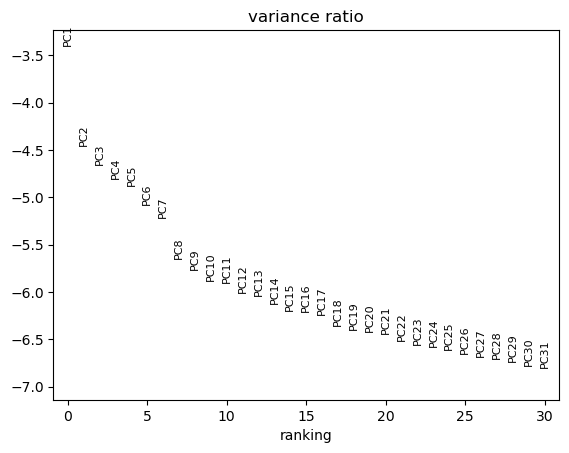

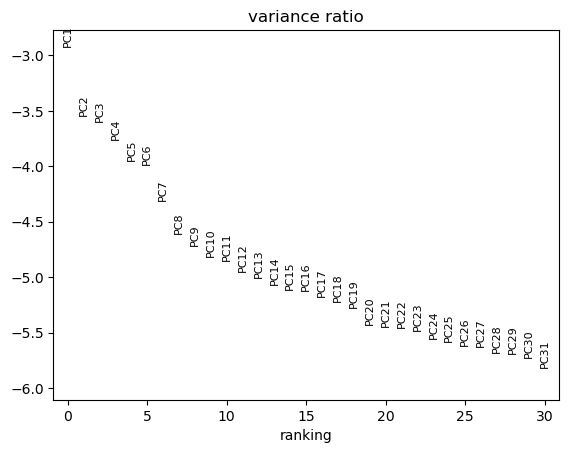

In [3]:
# Scale data
sc.pp.scale(adata1_hvg, max_value=10)
sc.pp.scale(adata2_hvg, max_value=10)

# PCA
sc.tl.pca(adata1_hvg, svd_solver="arpack")
sc.tl.pca(adata2_hvg, svd_solver="arpack")

# PCA variance plots
sc.pl.pca_variance_ratio(adata1_hvg, log=True)
sc.pl.pca_variance_ratio(adata2_hvg, log=True)

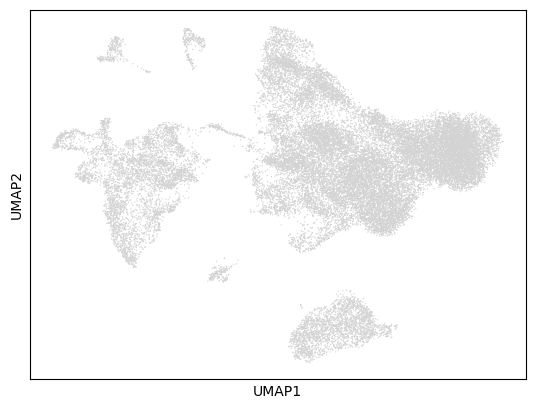

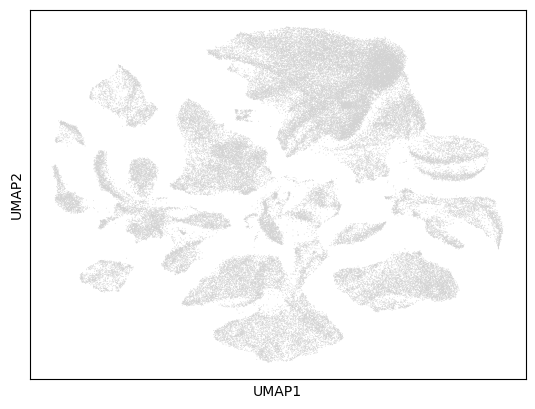

In [5]:
# Compute neighborhood graph
sc.pp.neighbors(adata1_hvg, n_neighbors=15, n_pcs=30)
sc.pp.neighbors(adata2_hvg, n_neighbors=15, n_pcs=30)

# UMAP embedding
sc.tl.umap(adata1_hvg)
sc.tl.umap(adata2_hvg)

# Plot UMAPs
sc.pl.umap(adata1_hvg)
sc.pl.umap(adata2_hvg)

In [6]:
!pip install leidenalg igraph

In [8]:
sc.tl.leiden(adata1_hvg, resolution=0.5)
sc.tl.leiden(adata2_hvg, resolution=0.5)

C:\Users\annam\AppData\Local\Temp\ipykernel_1188\2122192911.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata1_hvg, resolution=0.5)
C:\Users\annam\AppData\Local\Temp\ipykernel_1188\2122192911.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(

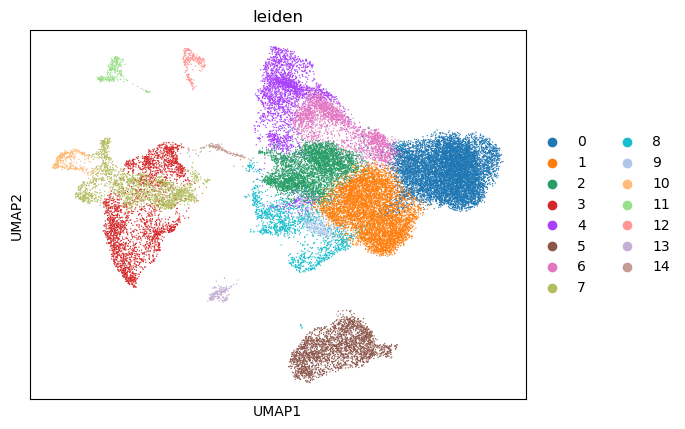

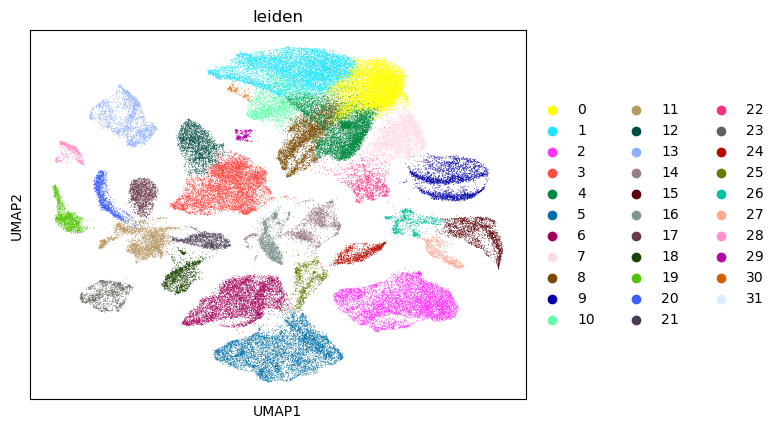

In [9]:
sc.pl.umap(adata1_hvg, color="leiden")
sc.pl.umap(adata2_hvg, color="leiden")

In [10]:
adata1_hvg.write("GSE114725_clustered.h5ad")
adata2_hvg.write("GSE176078_clustered.h5ad")